<a href="https://colab.research.google.com/github/zhesun0304/ECON3916/blob/main/Assignment%204/The_Predictive_Architecture_marked.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 0: install packages (run once per notebook)
%pip install -q missingno category_encoders

In [ ]:
# Step 0.1: concise imports + direct file loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import networkx as nx
import missingno as msno

from statsmodels.stats.outliers_influence import variance_inflation_factor
from category_encoders import TargetEncoder

vitals = pd.read_csv("OmniCare_Clinical_Vitals.csv")
tele = pd.read_csv("OmniCare_Telemetry_Data.csv")

Observed correlation between HDHP and inpatient admission rate: 0.3014

Omitted confounder: baseline wealth / systemic poverty
Fork structure:
Baseline wealth / poverty -> High_Deductible_Insurance_Plan
Baseline wealth / poverty -> Inpatient_Admission_Rate

Why the regression is biased:
If we regress Admission on HDHP alone, the omitted confounder enters the error term.
Because the confounder affects both HDHP and Admission, Cov(HDHP, error) != 0.
So the estimated coefficient on HDHP is contaminated by omitted-variable bias.

OVB formula:
beta_tilde = beta_true + gamma * Cov(HDHP, Z) / Var(HDHP)
where Z is the omitted confounder (poverty / low baseline wealth).


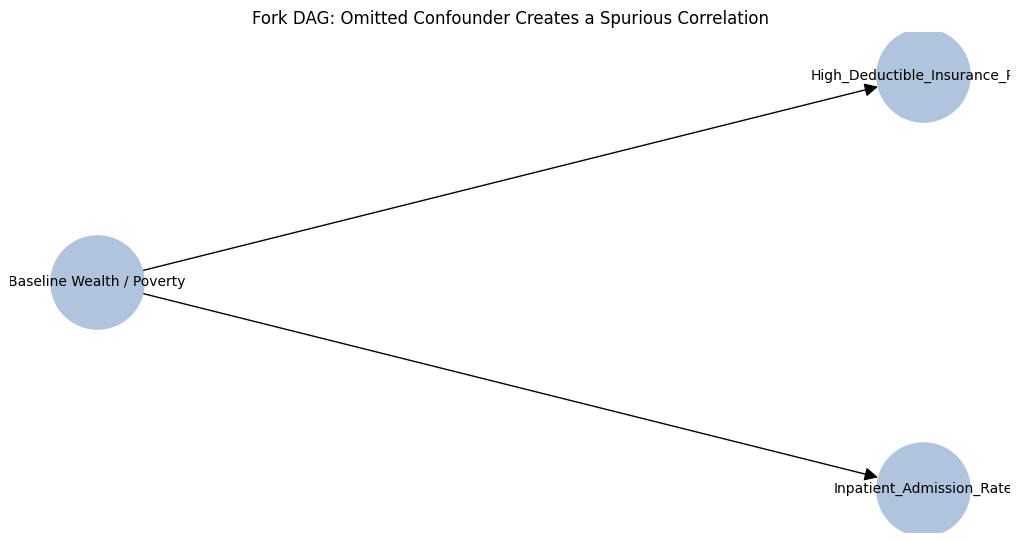

In [ ]:
# Step 1.1: DAG for spurious correlation

corr_val = tele[["High_Deductible_Insurance_Plan", "Inpatient_Admission_Rate"]].corr().iloc[0, 1]
print(f"Observed correlation between HDHP and inpatient admission rate: {corr_val:.4f}")

print("\nOmitted confounder: baseline wealth / systemic poverty")
print("Fork structure:")
print("Baseline wealth / poverty -> High_Deductible_Insurance_Plan")
print("Baseline wealth / poverty -> Inpatient_Admission_Rate")
print("\nWhy the regression is biased:")
print("If we regress Admission on HDHP alone, the omitted confounder enters the error term.")
print("Because the confounder affects both HDHP and Admission, Cov(HDHP, error) != 0.")
print("So the estimated coefficient on HDHP is contaminated by omitted-variable bias.")
print("\nOVB formula:")
print("beta_tilde = beta_true + gamma * Cov(HDHP, Z) / Var(HDHP)")
print("where Z is the omitted confounder (poverty / low baseline wealth).")

G = nx.DiGraph()
G.add_edges_from([
    ("Baseline Wealth / Poverty", "High_Deductible_Insurance_Plan"),
    ("Baseline Wealth / Poverty", "Inpatient_Admission_Rate")
])

pos = {
    "Baseline Wealth / Poverty": (0, 0),
    "High_Deductible_Insurance_Plan": (1.8, 0.8),
    "Inpatient_Admission_Rate": (1.8, -0.8)
}

plt.figure(figsize=(10, 5))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=4500,
    node_color="lightsteelblue",
    font_size=10,
    arrows=True,
    arrowsize=20
)
plt.title("Fork DAG: Omitted Confounder Creates a Spurious Correlation")
plt.axis("off")
plt.show()

**Interpretation:** The omitted confounder is baseline wealth or systemic poverty. This creates a classic **fork** structure because poverty can simultaneously affect the probability of enrolling in a high-deductible health plan and the probability of requiring inpatient care. As a result, the positive correlation between `High_Deductible_Insurance_Plan` and `Inpatient_Admission_Rate` does not by itself establish causation.

**Why the simple regression is biased:** If the omitted confounder \(Z\) affects both insurance choice and admissions, then \(Cov(HDHP, Z) \neq 0\). In that case, regressing admissions on insurance type alone violates the exogeneity condition and produces omitted-variable bias, so the coefficient on `High_Deductible_Insurance_Plan` is mathematically contaminated by the backdoor path through poverty.


In [ ]:
# Step 1.2: VIF audit before and after dropping the most redundant variable

continuous_features = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]

X_before = sm.add_constant(vitals[continuous_features])

vif_before = pd.DataFrame({
    "feature": X_before.columns,
    "VIF": [variance_inflation_factor(X_before.values, i) for i in range(X_before.shape[1])]
})

vif_before = vif_before[vif_before["feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)

print("Initial VIF table:")
print(vif_before)

high_vif = vif_before[vif_before["VIF"] > 10.0]["feature"].tolist()
print("\nFeatures with VIF > 10.0:", high_vif)

# Drop BMI because it is constructed from weight and height
reduced_features = ["Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]

X_after = sm.add_constant(vitals[reduced_features])

vif_after = pd.DataFrame({
    "feature": X_after.columns,
    "VIF": [variance_inflation_factor(X_after.values, i) for i in range(X_after.shape[1])]
})

vif_after = vif_after[vif_after["feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)

print("\nVIF table after dropping BMI:")
print(vif_after)

if (vif_after["VIF"] < 10.0).all():
    print("\nAll remaining features are below the critical threshold of 10.0.")
else:
    print("\nSome features still exceed 10.0 and may need further review.")

Initial VIF table:
        feature        VIF
0     Weight_kg  57.428058
1     Height_cm  28.419446
2           BMI  16.981232
3  Diastolic_BP   4.219820
4   Systolic_BP   4.219406

Features with VIF > 10.0: ['Weight_kg', 'Height_cm', 'BMI']

VIF table after dropping BMI:
        feature       VIF
0  Diastolic_BP  4.219820
1   Systolic_BP  4.219406
2     Weight_kg  3.763969
3     Height_cm  3.763812

All remaining features are below the critical threshold of 10.0.


**Interpretation of the VIF audit:** The initial VIF results show severe multicollinearity, especially among the physiological size variables. This is expected because `BMI` is mechanically constructed from weight and height, so keeping all three in the same regression creates redundant information.

**Why `BMI` was dropped:** `BMI` is the most conceptually redundant variable because it is derived from `Weight_kg` and `Height_cm`. Removing it preserves the underlying physical measurements while relieving multicollinearity.

**Conclusion:** After dropping `BMI`, the remaining VIF values fall below the critical threshold of 10, which indicates that the sanitized vital-sign feature set is structurally more stable for OLS estimation.


Missingness rates (%):
Continuous_Heart_Rate             24.28
Patient_ID                         0.00
High_Deductible_Insurance_Plan     0.00
Inpatient_Admission_Rate           0.00
Primary_Diagnosis_Code             0.00
Clinic_Capacity_Percentage         0.00
Time_of_Day_Index                  0.00
Procedure_Cost_USD                 0.00
dtype: float64


<Figure size 1400x600 with 0 Axes>

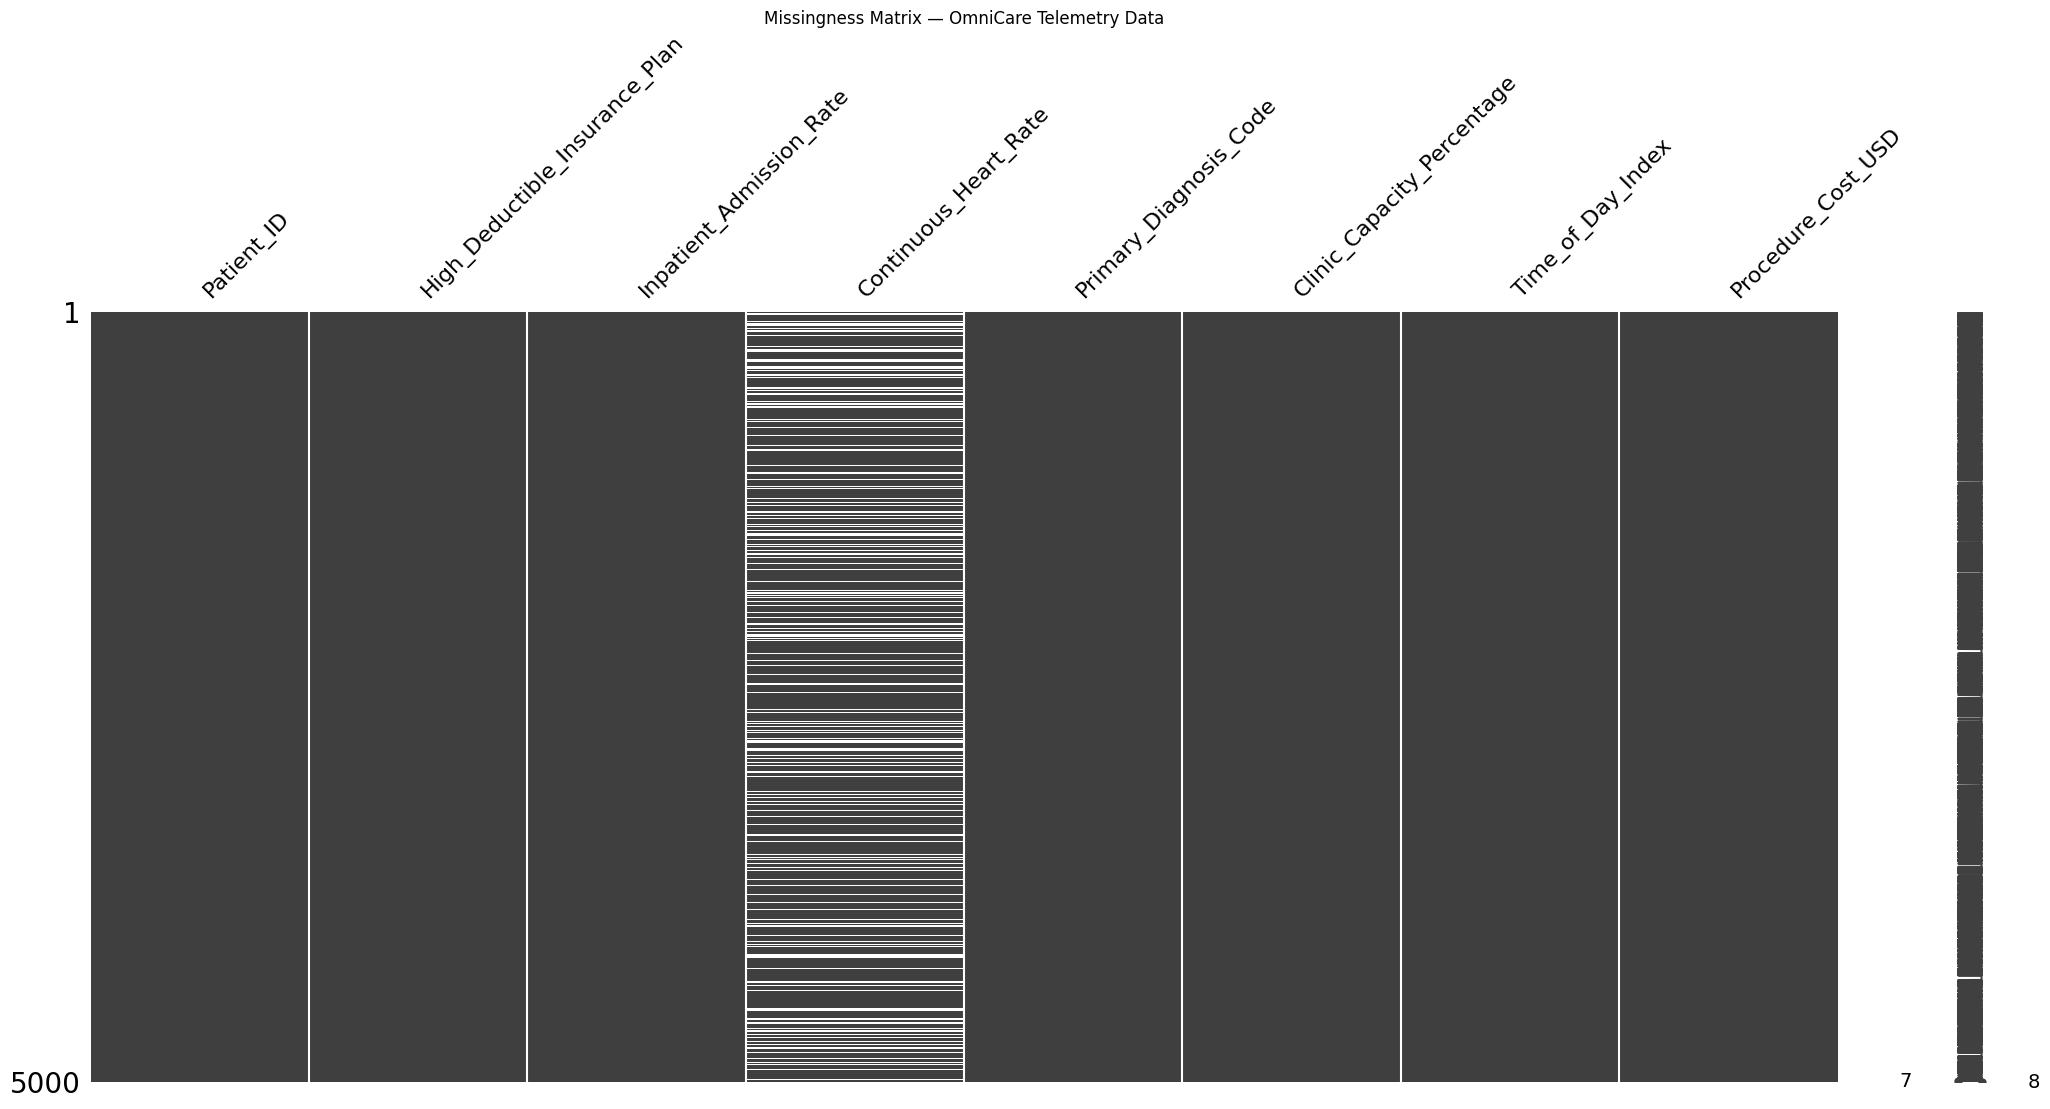


Continuous_Heart_Rate missingness: 24.28%

Rubin taxonomy classification:
This is MNAR under the current dataset setup.
Reason: if missingness happens because low-income patients avoid telemetry transmission
due to data-plan costs, then missingness depends on an unobserved socioeconomic factor.
So it is not MCAR, and without observed income in the dataset it is not safely MAR.

Why mean imputation is bad here:
- It shrinks variance
- It weakens covariance with other variables
- It erases subgroup structure
- It biases downstream analysis because missingness is systematic, not random


In [ ]:
# Step 2.1: missingness matrix + classification

missing_pct = (tele.isna().mean() * 100).sort_values(ascending=False).round(2)
print("Missingness rates (%):")
print(missing_pct)

plt.figure(figsize=(14, 6))
msno.matrix(tele)
plt.title("Missingness Matrix — OmniCare Telemetry Data")
plt.show()

heart_rate_missing_pct = tele["Continuous_Heart_Rate"].isna().mean() * 100
print(f"\nContinuous_Heart_Rate missingness: {heart_rate_missing_pct:.2f}%")

print("\nRubin taxonomy classification:")
print("This is MNAR under the current dataset setup.")
print("Reason: if missingness happens because low-income patients avoid telemetry transmission")
print("due to data-plan costs, then missingness depends on an unobserved socioeconomic factor.")
print("So it is not MCAR, and without observed income in the dataset it is not safely MAR.")
print("\nWhy mean imputation is bad here:")
print("- It shrinks variance")
print("- It weakens covariance with other variables")
print("- It erases subgroup structure")
print("- It biases downstream analysis because missingness is systematic, not random")

**Rubin taxonomy classification:** Under this scenario, the missingness in `Continuous_Heart_Rate` is best classified as **MNAR** in the current dataset setup. The reason is that the probability of missingness depends on an unobserved socioeconomic factor—patient income or poverty status—which is not explicitly included in the telemetry file.

**Why this is not MCAR:** The gaps are not random noise; they occur systematically among low-income patients who avoid data transmission costs.

**Why mean imputation is inappropriate:** Mean imputation would overwrite a structured missingness mechanism with a single artificial average value. That would shrink the variance of heart-rate measurements, weaken real correlations with other variables, and erase meaningful subgroup differences. In other words, mean imputation would destroy the integrity of the data-generating process rather than repair it.


In [ ]:
# Step 2.2: dummy variable trap

n_unique_dx = tele["Primary_Diagnosis_Code"].nunique()
print(f"Distinct Primary_Diagnosis_Code values in this file: {n_unique_dx}")

dummies = pd.get_dummies(
    tele["Primary_Diagnosis_Code"],
    prefix="DX",
    drop_first=False,
    dtype=int
)

design = dummies.copy()
design.insert(0, "const", 1)

row_sum_of_dummies = dummies.sum(axis=1)
max_abs_dependency_error = np.abs(design["const"] - row_sum_of_dummies).max()

print(f"Number of dummy columns created: {dummies.shape[1]}")
print(f"Max absolute difference between intercept and sum of all dummy columns: {max_abs_dependency_error}")

print("\nMatrix algebra explanation:")
print("With K diagnosis categories, one-hot encoding creates D1, D2, ..., DK.")
print("Because each patient belongs to exactly one diagnosis category,")
print("D1 + D2 + ... + DK = 1 for every row.")
print("If an intercept is also included, then:")
print("Intercept = D1 + D2 + ... + DK")
print("So one column is an exact linear combination of the others.")
print("That makes the design matrix rank-deficient and X'X singular.")
print("Therefore, the classical OLS inverse (X'X)^(-1) does not exist.")

Distinct Primary_Diagnosis_Code values in this file: 847
Number of dummy columns created: 847
Max absolute difference between intercept and sum of all dummy columns: 0

Matrix algebra explanation:
With K diagnosis categories, one-hot encoding creates D1, D2, ..., DK.
Because each patient belongs to exactly one diagnosis category,
D1 + D2 + ... + DK = 1 for every row.
If an intercept is also included, then:
Intercept = D1 + D2 + ... + DK
So one column is an exact linear combination of the others.
That makes the design matrix rank-deficient and X'X singular.
Therefore, the classical OLS inverse (X'X)^(-1) does not exist.


**Why the dummy variable trap occurs:** If `Primary_Diagnosis_Code` has \(K\) exhaustive categories, then one-hot encoding creates \(K\) binary columns \(D_1, D_2, ..., D_K\). Because each patient belongs to exactly one diagnosis category, the row-wise sum of all dummy columns equals 1.

\[
D_1 + D_2 + ... + D_K = 1
\]

If the regression also includes a constant intercept term, then the intercept column is an exact linear combination of the diagnosis dummies:

\[
1 = D_1 + D_2 + ... + D_K
\]

That makes the design matrix rank-deficient, so \(X'X\) becomes singular and the classical OLS inverse does not exist.


In [ ]:
# Step 2.3: target encoding for Primary_Diagnosis_Code

encoder = TargetEncoder(cols=["Primary_Diagnosis_Code"])

encoded_col = encoder.fit_transform(
    tele[["Primary_Diagnosis_Code"]],
    tele["Procedure_Cost_USD"]
)

tele["Primary_Diagnosis_Code_TE"] = encoded_col["Primary_Diagnosis_Code"]

print("First five rows of the target-encoded variable:")
print(tele[["Primary_Diagnosis_Code", "Primary_Diagnosis_Code_TE"]].head())

First five rows of the target-encoded variable:
  Primary_Diagnosis_Code  Primary_Diagnosis_Code_TE
0                J86.381                1707.697108
1                M29.789                1792.303198
2                E49.618                1730.334968
3                E66.244                1725.060944
4                J45.553                1801.821085


**Why target encoding is appropriate here:** `Primary_Diagnosis_Code` is a high-cardinality categorical variable, so one-hot encoding would create an unnecessarily large and sparse feature space. Target encoding solves this by mapping each diagnosis code to the historical mean of `Procedure_Cost_USD`, compressing hundreds of medical strings into one continuous predictor.

**Benefit for the model:** This preserves useful cost information while avoiding the dummy explosion and computational instability that would result from full one-hot encoding.


In [ ]:
# Step 3.1: OLS Optimization via Patsy Formulas
import statsmodels.formula.api as smf

tele_model = tele.copy()
tele_model["Target_Encoded_Diagnosis"] = TargetEncoder(
    cols=["Primary_Diagnosis_Code"]
).fit_transform(
    tele[["Primary_Diagnosis_Code"]],
    tele["Procedure_Cost_USD"]
)["Primary_Diagnosis_Code"]

final_df = tele_model[
    [
        "Patient_ID",
        "Procedure_Cost_USD",
        "Target_Encoded_Diagnosis",
        "Clinic_Capacity_Percentage",
        "Time_of_Day_Index"
    ]
].merge(
    vitals[
        [
            "Patient_ID",
            "Weight_kg",
            "Height_cm",
            "Systolic_BP",
            "Diastolic_BP"
        ]
    ],
    on="Patient_ID",
    how="inner"
).dropna()

formula = (
    "Procedure_Cost_USD ~ Target_Encoded_Diagnosis + "
    "Clinic_Capacity_Percentage + Time_of_Day_Index + "
    "Weight_kg + Height_cm + Systolic_BP + Diastolic_BP"
)

ols_model = smf.ols(formula=formula, data=final_df).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          6.83e-296
Time:                        22:33:36   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                  -6435.2984    265.120    -24.273      0.000   -6955.050   -5915.547
Target_Encoded_Diagnosis       4.3813      0.145     30.277      0.000       4.098       4.665
Clinic_Capacity_Percentage   426.0942     32.844     12.973      0.000     361.706     490.482
Time_of_Day_Index             12.8237      0.711     18.042      0.000      11.430      14.217
Weight_kg                      0.1073      0.586      0.183      0.855      -1.042       1.257
Height_cm                     -0.0874      0.615     -0.142      0.887      -1.294       1.119
Systolic_BP                    0.0231      0.649      0.036      0.972      -1.250       1.296
Diastolic_BP                   0.2717      0.940      0.289      0.773      -1.572       2.115
==============================================================================
Omnibus:                        4.174   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.124   Jarque-Bera (JB):                4.543
Skew:                          -0.000   Prob(JB):                        0.103
Kurtosis:                       3.148   Cond. No.                     9.91e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.91e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Model architecture:** The final analytical dataframe merges the telemetry dataset with the sanitized vital-sign features by `Patient_ID`. The OLS model regresses `Procedure_Cost_USD` on:

- Target_Encoded_Diagnosis
- Clinic_Capacity_Percentage
- Time_of_Day_Index`
- Weight_kg
- Height_cm
- Systolic_BP
- Diastolic_BP

**Why this specification is valid for Phase 3:** The diagnosis variable is encoded into a low-dimensional continuous feature, and `BMI` has already been excluded to reduce multicollinearity. This produces a cleaner design matrix for linear estimation.


In [ ]:
# Step 3.2: Financial Loss Quantification (RMSE)
from statsmodels.tools.eval_measures import rmse

rmse_value = rmse(final_df["Procedure_Cost_USD"], ols_model.fittedvalues)
rmse_value

np.float64(334.80215211463116)

**RMSE interpretation:** RMSE translates model error into the original unit of analysis, which is US dollars. In this notebook, the fitted model's RMSE is approximately **$334.80**, meaning the typical prediction error is several hundred dollars per procedure.

**Why this matters operationally:** If a typical outpatient MRI costs about $1,200, then an RMSE on the order of a few hundred dollars is substantial. An error like this could cause systematic underpricing, which reduces hospital revenue, or overpricing, which harms patients and increases billing disputes.

**Why this matters financially and regulatorily:** In a live hospital environment, large dollar errors can trigger reimbursement problems with insurers, fairness concerns across patients, and scrutiny under healthcare billing and transparency standards. So RMSE is not just a technical metric; it is a direct measure of deployment risk.


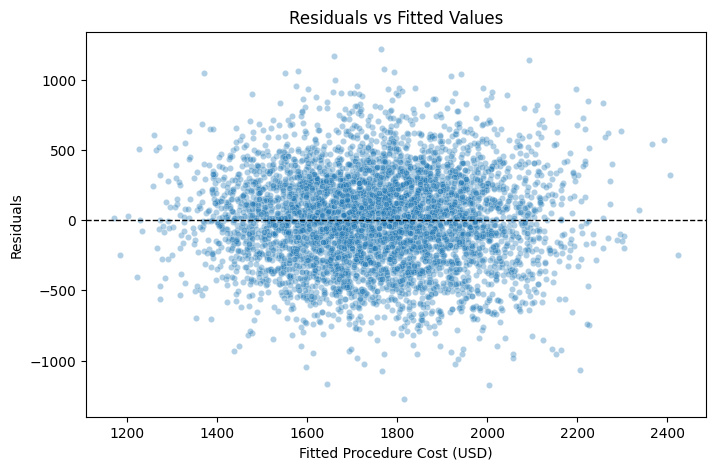

In [ ]:
# Step 3.3: Residual Diagnostics for Heteroscedasticity
import seaborn as sns

residual_df = pd.DataFrame({
    "Fitted_Values": ols_model.fittedvalues,
    "Residuals": ols_model.resid
})

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=residual_df,
    x="Fitted_Values",
    y="Residuals",
    alpha=0.35,
    s=20
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Fitted Procedure Cost (USD)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

**Visual diagnosis:** The residual plot should be inspected for whether the vertical spread of the residuals stays roughly constant as fitted values increase. A widening or fan-shaped pattern indicates **heteroscedasticity**, meaning the model makes larger absolute errors at higher predicted procedure costs.

**Implication for reliability:** That structural flaw would mean the pricing model is least reliable exactly where prices are highest. In surge-pricing or high-cost tiers, even moderate heteroscedasticity is dangerous because the largest dollar mistakes occur in the most financially sensitive cases.

**Bottom line:** If the residual band widens as fitted values rise, the algorithm should not be treated as equally reliable across the full price range.


# Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)
You are an expert applied econometrician and Python developer working in Google Colab.

Role:
Your job is to generate clean, executable Python code for post-OLS diagnostic testing on an already-fitted statsmodels regression object.

Instructions:
Write a Python code block that performs White’s Lagrange Multiplier Test for heteroscedasticity using `statsmodels.stats.diagnostic.het_white`. Assume I already have an OLS model object named `ols_model` in memory from this exact formula:

Procedure_Cost_USD ~ Target_Encoded_Diagnosis + Clinic_Capacity_Percentage + Time_of_Day_Index + Weight_kg + Height_cm + Systolic_BP + Diastolic_BP

The code must:
1. Import `het_white`
2. Run the test using `ols_model.resid` and `ols_model.model.exog`
3. Store the outputs as:
   - `white_lm_stat`
   - `white_lm_pvalue`
   - `white_f_stat`
   - `white_f_pvalue`
4. Return the results in a compact pandas Series or DataFrame
5. Add one final line of code that states whether the null hypothesis of homoscedasticity is rejected at the 5% level

Meaning:
This test is for a hospital procedure-cost pricing model, so I need a precise econometric diagnostic for whether the residual variance is constant. The code must be directly usable in Colab and must not refit the model.

Evaluation:
Your answer is correct only if it is valid Python, runs without modification in Colab, uses the exact existing object name `ols_model`, applies `het_white` correctly, and clearly reports the LM p-value plus the final conclusion.

In [ ]:
# AI Context Engineering (The P.R.I.M.E. Framework)
from statsmodels.stats.diagnostic import het_white

white_lm_stat, white_lm_pvalue, white_f_stat, white_f_pvalue = het_white(
    ols_model.resid,
    ols_model.model.exog
)

white_results = pd.Series({
    "White_LM_Statistic": white_lm_stat,
    "White_LM_pvalue": white_lm_pvalue,
    "White_F_Statistic": white_f_stat,
    "White_F_pvalue": white_f_pvalue
})

white_results

,0
White_LM_Statistic,1.864677e+02
White_LM_pvalue,1.438029e-22
White_F_Statistic,5.494188e+00
White_F_pvalue,4.479023e-23


**White's LM test conclusion:** The LM p-value is approximately **1.44e-22**, which is far below the conventional 0.05 significance threshold.

**Decision:** We therefore **reject the null hypothesis of homoscedasticity**.

**Interpretation:** This means the residual variance is not constant, providing formal statistical evidence that the OLS model suffers from heteroscedasticity. That result supports the concern already raised by the residual-versus-fitted diagnostic plot.
